In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [10]:
df = pd.read_csv("train_cleaned.csv")
df

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [17]:
df.isnull().sum().sort_values(ascending = False)

age            177
embarked         2
passengerid      0
pclass           0
survived         0
sex              0
name             0
sibsp            0
parch            0
ticket           0
fare             0
dtype: int64

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

#column

num_colm = ["age", "fare"]
cat_colm = ["sex","embarked","pclass"]

#numeric median preprocessing pipline

num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy = 'median'))  
])

#categorical preprocessing pipeline

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

#combine both

preprocessor = ColumnTransformer([
    ('num',num_pipeline,num_colm),
    ('co',cat_pipeline,cat_colm)
])


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [46]:
X = df.drop("survived", axis = 1)
y = df["survived"]


X_train,X_test,y_train,y_test = train_test_split(
    X, y, 
    test_size = 0.2,
    random_state = 42,
    stratify=y
)
print("Data split done!")

Data split done!


In [55]:
model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000)),
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [56]:
rf_model = Pipeline([
    ('preprocessing', preprocessor),   
    ('classifier', RandomForestClassifier(random_state=42))  
])

#train
rf_model.fit(X_train, y_train)

#predict
y_pred_rf = rf_model.predict(X_test)

In [57]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix


print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

Logistic Regression:
Accuracy: 0.770949720670391
F1: 0.6917293233082706
ROC-AUC: 0.7515151515151515

Random Forest:
Accuracy: 0.8212290502793296
F1: 0.7575757575757576
ROC-AUC: 0.8032279314888011


In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)# for Logistic Regression
cm_rf = confusion_matrix(y_test, y_pred_rf) #randomforest
print(cm)
print(cm_rf)

[[92 18]
 [23 46]]
[[97 13]
 [19 50]]


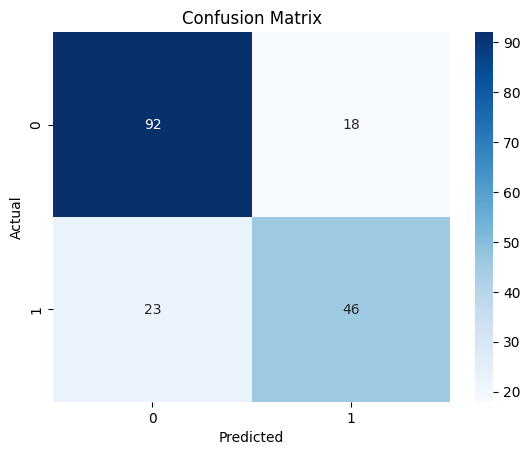

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("../reports/figures/confusion_matrix.png", bbox_inches="tight", dpi=200)

plt.show()

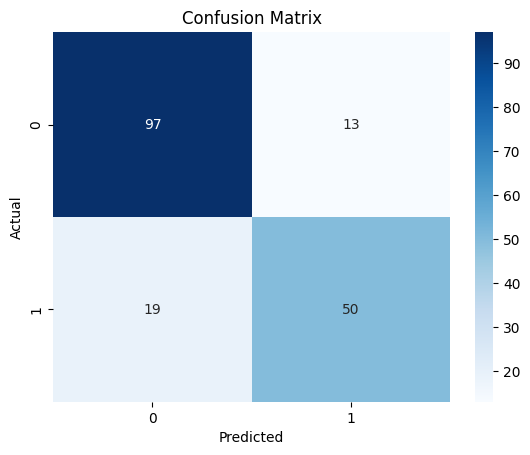

In [61]:
plt.figure()

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("../reports/figures/confusion_matrix_rf.png", bbox_inches="tight", dpi=200)

plt.show()